# Free energy diagram

This notebook introduces the Computational Hydrogen Electrode (CHE) framework, which is the standard approach for converting DFT or semiempirical total energies into free energy diagrams for electrochemical reactions without explicitly simulating the electrode potential or the solvent.

The core idea of the CHE is that at equilibrium, the free energy of a proton-electron pair (H⁺ + e⁻) equals half the free energy of H₂. This allows each proton-coupled electron transfer step in the ORR mechanism to be shifted by the electrode potential U simply by subtracting nU from the free energy of each intermediate. The result is a four-step free energy diagram connecting O₂ through OOH*, O*, and OH* to H₂O, whose downhill slope at a given potential determines whether the reaction is thermodynamically spontaneous at each step. The limiting potential is the smallest potential at which all steps become downhill, and the difference from the equilibrium potential (1.23 V) is the thermodynamic overpotential.
The notebook is organized in two parts. The first uses UMA (FAIRChem's universal machine-learning interatomic potential) as the calculator to compute adsorption energies for Pt(111), applies empirical ZPE and solvation corrections, and plots the free energy diagram at three potentials: 0 V, the equilibrium potential, and the limiting potential. The second part downloads a Zenodo database of BEEF-vdW DFT results for eight transition metals, reads it into a pandas DataFrame with the ASE database interface, recomputes adsorption energies with the same Hess cycle expressions, and generates an equivalent diagram for Au, enabling direct comparison between UMA and DFT.


In [1]:
######################################################
##-install the necessery packages for this tutorial-##
######################################################

%%capture
!pip install fairchem-core --upgrade
!pip install ase

In [2]:
#########################
##-Importing libraries-##
#########################

##-Computational imports
from ase import Atom, Atoms
from ase.build import fcc111, add_adsorbate, molecule, graphene_nanoribbon
from ase.constraints import FixAtoms, FixedLine
from ase.data import atomic_numbers, reference_states
from ase.data.pubchem import pubchem_atoms_search
from ase.db import connect
from ase.io import read, write
from ase.io.trajectory import Trajectory
from ase.optimize import BFGS
from ase.visualize import view

from fairchem.core import FAIRChemCalculator, pretrained_mlip

##-general python packages
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import re
import time
from dataclasses import dataclass

The UMA model is distributed under the FAIR Chemistry License by Meta, available at https://huggingface.co/facebook/UMA/blob/main/LICENSE. By running this notebook you agree to its terms. To use the model in your own environment, go to Hugging Face (huggingface.co), create an account, generate an access token under Settings > Access Tokens, and download the model via the fairchem API. Since tokens are personal and should not be shared, in this notebook we provide the model file via a direct Google Drive link instead.

In [3]:
!gdown 1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX -O uma-s-1p1.pt

Downloading...
From (original): https://drive.google.com/uc?id=1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX
From (redirected): https://drive.google.com/uc?id=1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX&confirm=t&uuid=2025d403-3ffd-4314-bb91-debe9b57f612
To: /content/uma-s-1p1.pt
100% 1.17G/1.17G [00:17<00:00, 67.3MB/s]


Adjust the graphical settings

In [4]:
l = 8.25/2.54 # inches
plt.rc('figure',figsize=(l,l)) # figure size
plt.rc('figure',      dpi=100) # figure dpi
plt.rc('lines',  linewidth=4)  # linewidth
plt.rc('font',        size=10) # fontsize of the text
plt.rc('font', family='sans-serif') # font family
plt.rc('axes',   titlesize=10) # fontsize of the axes title
plt.rc('axes',   labelsize=9)  # fontsize of the x and y labels
plt.rc('xtick',  labelsize=8)  # fontsize of the tick labels
plt.rc('ytick',  labelsize=8)  # fontsize of the tick labels
plt.rc('legend', fontsize =8)  # fontsize of the legend
plt.rc('figure', titlesize=10) # fontsize of the figure title
# Tol's color scheme
colors = ['#1965B0', '#7BAFDE', '#90C987', '#F1932D', '#DC050C']

We start by refactoring the workflow into reusable functions:get_calculator, add_adsorbate_to_atoms, set_position_constraints, and relax.

So that instead of copying and pasting large code blocks, we can simply call a function with the metal and adsorbate of interest. This is a good habit whenever you find yourself repeating the same steps.

In [23]:
unit = pretrained_mlip.load_predict_unit('uma-s-1p1.pt', device='cpu')
calc = FAIRChemCalculator(unit, task_name='omat')

def relax_slab(fmax=0.05, maxsteps=115, Nx=2, Ny=2, Nz=3):
  atoms = fcc111('Pt', (Nx, Ny, Nz), a=3.9936, vacuum=10.0)

  atoms.pbc = [True, True, True]
  atoms.set_constraint(FixAtoms(mask=[atom.index < Nx*Ny*(Nz-1) for atom in atoms]))

  atoms.calc = calc

  opt = BFGS(atoms, f'{metal}_slab.traj', f'{metal}_slab.log')
  opt.run(fmax=fmax, steps=maxsteps)

  return atoms, atoms.get_potential_energy()


def relax_adsorbate(slab, adsorbate, position, Nx=2, Ny=2, Nz=3, fmax=0.05, maxsteps=115):
  atoms = slab.copy()

  ##-I think this is fine as is, since it is quite logical to use a dictionary here
  ##-But we need to add a description of how it works, as in what is in the dictionary
  ##-Maybe even say what is a dictionary first, I think it was not covered in the introductory python notebook

  adsorbates = {
      'O': (Atoms('O', positions=[(0, 0, 0)]), 1.5),
      'OH': (Atoms('OH', positions=[(0, 0, 0), (0.7, 0, 0.7)]), 1.8),
      'OOH': (Atoms('OOH', positions=[(0, 0, 0), (0.1, 0, 1.5), (0.7, 0, 2.2)]), 1.8),
  }

  ads, height = adsorbates[adsorbate]
  add_adsorbate(atoms, ads, height, position)
  atoms.set_constraint(FixAtoms(mask=[atom.index < Nx*Ny*(Nz-1) for atom in atoms]))

  atoms.calc = calc

  opt = BFGS(atoms, f'{metal}_{adsorbate}.traj', f'{metal}_{adsorbate}.log')
  opt.run(fmax=fmax, steps=maxsteps)

  return atoms.get_potential_energy()


def adsorption_energies(E_slab, E_slab_O, E_slab_OH, E_slab_OOH, H2O_ref, H2_ref):
  H2O_ref += 0.56 - 0.67  ##-H2O_ZPE - H2O_TS
  H2_ref  += 0.27 - 0.41  ##-H2_ZPE  - H2_TS

  E_O   = E_slab_O   - E_slab - (H2O_ref -       H2_ref) + 0.07  ##-O_ZPE
  E_OH  = E_slab_OH  - E_slab - (H2O_ref - 0.5 * H2_ref) + 0.00  ##-OH_ZPE - E_solv cancel
  E_OOH = E_slab_OOH - E_slab - (2 * H2O_ref - 1.5 * H2_ref) + 0.09  ##-OOH_ZPE - E_solv
  return E_O, E_OH, E_OOH

Before calculating adsorption energies, we need reference energies for H₂ and H₂O. These molecules appear in every Hess cycle expression, so we optimize them first and store their energies.

In [24]:
##-Optimizig H2
H2 = molecule('H2')

H2.calc = calc

opt = BFGS(H2, trajectory='H2.traj', logfile='H2.log')
opt.run(fmax=0.01, steps=53)

H2_ref = H2.get_potential_energy()

##-Optimizing H2O
H2O = molecule('H2O')

H2O.calc = calc
BFGS(H2O, trajectory='H2O.traj', logfile='H2O.log').run(fmax=0.01, steps=53)

H2O_ref = H2O.get_potential_energy()

With the helper functions defined, we now optimize a Pt(111) slab and each slab+adsorbate combination (O, OH, OOH), storing the resulting energies in a pandas dataframe.

In [25]:
##-Rewrote this part, and the functions manually, should work now.
##-Wont work on recalculation since slab is redefined

slab, E_slab = relax_slab()
E_slab_O = relax_adsorbate(slab, 'O', position='ontop')
E_slab_OH = relax_adsorbate(slab, 'OH', position='ontop')
E_slab_OOH = relax_adsorbate(slab, 'OOH', position='ontop')

E_O, E_OH, E_OOH = adsorption_energies(E_slab, E_slab_O, E_slab_OH, E_slab_OOH, H2O_ref, H2_ref)
print(f"Pt: E_O={E_O:.3f}, E_OH={E_OH:.3f}, E_OOH={E_OOH:.3f}")

Pt: E_O=2.521, E_OH=0.734, E_OOH=3.645


The `plot_at_U` function traces the ORR free energy pathway:

 from \*+O₂ through OOH\*, O\*, OH\*, to \*+H₂O

  at a chosen electrode potential. We plot three potentials: the equilibrium potential (1.23 V), the limiting potential, and 0 V. The gap between the equilibrium and limiting potentials is the overpotential.

In [27]:
##-Updated function to plot the free energy diagram with horizontal bars and dotted lines
def plot_at_U(U, Es, color='#0000cc', metal="Pt", peroxide=False):
    states = [
        4.92 -  4 * U,
        Es[0] - 3 * U,
        Es[1] - 2 * U,
        Es[2] - 1 * U,
        0
    ]

    if peroxide:
        ##-plt.plot([0.8, 1.2], [states[1], states[1]], c='#DC050C', linestyle='-', linewidth=3, alpha=1, zorder=10)
        plt.plot([1.2, 1.8], [states[1], 4.92-0.68*2-2*U], c='#DC050C', linestyle=':', linewidth=1, zorder=10)
        plt.plot([1.8, 2.2], [4.92-0.68*2-2*U, 4.92-0.68*2-2*U], c='#DC050C', linestyle='-', linewidth=3, alpha=1, zorder=10)

    plt.plot([-0.2, 0.2], [states[0], states[0]], c=f'{color}', linestyle='-', linewidth=3, label=f"{metal}, $U$={U} V")
    plt.plot([ 0.8, 1.2], [states[1], states[1]], c=f'{color}', linestyle='-', linewidth=3)
    plt.plot([ 1.8, 2.2], [states[2], states[2]], c=f'{color}', linestyle='-', linewidth=3)
    plt.plot([ 2.8, 3.2], [states[3], states[3]], c=f'{color}', linestyle='-', linewidth=3)
    plt.plot([ 3.8, 4.2], [states[4], states[4]], c=f'{color}', linestyle='-', linewidth=3)

    plt.plot([0.2, 0.8], [states[0], states[1]], c=f'{color}', linestyle=':', linewidth=1)
    plt.plot([1.2, 1.8], [states[1], states[2]], c=f'{color}', linestyle=':', linewidth=1)
    plt.plot([2.2, 2.8], [states[2], states[3]], c=f'{color}', linestyle=':', linewidth=1)
    plt.plot([3.2, 3.8], [states[3], states[4]], c=f'{color}', linestyle=':', linewidth=1)

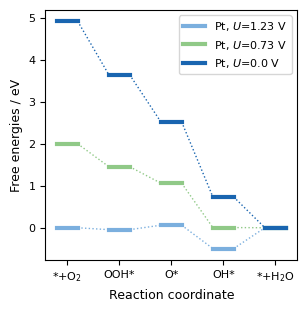

In [28]:
plt.figure()

Es = [E_OOH, E_O, E_OH]
UL = round(1.23 - min(4.92 - Es[0], Es[0] - Es[1], Es[1] - Es[2], Es[2]), 2)

plot_at_U(1.23, Es, colors[1])
plot_at_U(round(1.23-UL, 2), Es, colors[2])
plot_at_U(0.00, Es, colors[0])

plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ["*+O$_2$", "OOH*", "O*", "OH*", "*+H$_2$O"])
plt.legend()
plt.show()

##-Overpotential is calculated to be 1.23-0.73=0.5, actual calculated value is around 0.37, sus

So far we have used UMA as our calculator. We now switch to literature DFT data computed with the BEEF-vdW functional, downloaded from a Zenodo database.

In [29]:
%%capture
!wget https://zenodo.org/records/19023993/files/molecules.db
!wget https://zenodo.org/records/19023993/files/slab_database.db
!wget https://zenodo.org/records/19023993/files/adsorbate_database.db

We start by going through every row in the database for the bare slabs and select those marked with the BEEF-vdW functional. To better work with the data within Python we sort it all into a pandas dataframe.

In [31]:
df = pd.DataFrame(columns=['metal', 'adsorbate', 'energy', 'position'])

slabs_db = connect('slab_database.db')
for row in slabs_db.select(xc='BEEF-vdW'):
  metal = row.structure_str.split('_')[0]

  adsorbate = "_"
  position = "_"

  energy = row.get('energy')
  new_row = pd.DataFrame(
      {
          'metal': [metal],
          'adsorbate': [adsorbate],
          'position': [position],
          'energy': [energy],
      }
  )

  df = pd.concat([df, new_row], ignore_index=True)

df

/tmp/ipykernel_1674/2313689517.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)
/tmp/ipykernel_1674/2313689517.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)
/tmp/ipykernel_1674/2313689517.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the res

,metal,adsorbate,energy,position
0,Pt,_,-11878.128475,_
1,Cu,_,-2722.094801,_
2,Ag,_,-5335.580912,_
3,Pd,_,-5195.035952,_
4,Ir,_,-11720.923139,_
5,Rh,_,-5140.258546,_
6,Au,_,-12026.413827,_
7,Ni,_,-2712.408826,_
8,Ag,_,NaN,_
9,Au,_,NaN,_


As before, we do the same for the adsorbate database, filtering for the ontop adsorption site and non-null energies.

In [32]:
ads_db = connect('adsorbate_database.db')
for row in ads_db.select(xc='BEEF-vdW'):
  metal = row.structure_str.split('_')[0]

  adsorbate = row.structure_str.split('_')[2]
  position = row.structure_str.split('_')[3]

  energy = row.get('energy')

  if position == 'top' and energy is not None:
    new_row = pd.DataFrame(
        {
            'metal': [metal],
            'adsorbate': [adsorbate],
            'position': [position],
            'energy': [energy],
        }
    )

    df = pd.concat([df, new_row], ignore_index=True)

df

,metal,adsorbate,energy,position
0,Pt,_,-11878.128475,_
1,Cu,_,-2722.094801,_
2,Ag,_,-5335.580912,_
3,Pd,_,-5195.035952,_
4,Ir,_,-11720.923139,_
5,Rh,_,-5140.258546,_
6,Au,_,-12026.413827,_
7,Ni,_,-2712.408826,_
8,Ag,_,NaN,_
9,Au,_,NaN,_


With the new pandas dataframe populated, we retrieve the BEEF-vdW molecular reference energies from the database and apply the  `calculate_adsorption_energy` function to compute corrected adsorption free energies for all eight metals.

In [33]:
mol_db = connect("molecules.db")
E_H2O = mol_db.get(xc='BEEF-vdW', formula="H2O").energy
E_H2 = mol_db.get(xc='BEEF-vdW', formula="H2").energy

In [34]:
def calculate_adsorption_energy(df, metal, adsorbate, E_H2, E_H2O):
  ##-We can keep as is, but we need to explain what iloc does (indexing), and why we need it
  ##-Had to go back to studying so didn't do that but link to iloc explanation: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html

  ##-We create two new dataframes, one where there are only slabs,
  ##-and the other where there are only slab adsorbate systems
  row_slab = df[(df['metal'] == metal) & (df['adsorbate'] == '_')].iloc[0]
  row_ads  = df[(df['metal'] == metal) & (df['adsorbate'] == adsorbate)].iloc[0]

  ##-From the new dataframes, we get the energy values into a list
  E_slab = row_slab['energy']
  E_slab_ads = row_ads['energy']

  ##-based on the adsorbate, the adsortption energy is calculated differently
  ##-This is from the electron transfers
  ##-Using CHE we simplified that e- + H+ = 1/2H2
  if adsorbate == 'OH':
    return E_slab_ads - E_slab - E_H2O + 0.5 * E_H2

  elif adsorbate == 'O':
    return E_slab_ads - E_slab - E_H2O + E_H2

  elif adsorbate == 'OOH':
    return E_slab_ads - E_slab - 2 * E_H2O + 1.5 * E_H2

  else:
    raise ValueError(f"Unknown adsorbate: {adsorbate}")

##-Iterate over each row in the filtered dataframe
adsorption_energies = []

for index, row in df.iterrows():
  ##-Skip if adsorbate is '_'
  if row['adsorbate'] == '_':
    adsorption_energies.append(None)  # Skip this row

  else:
    ##-Calculate adsorption energy for OOH or OH
    energy = calculate_adsorption_energy(df, row['metal'], row['adsorbate'], E_H2, E_H2O)
    adsorption_energies.append(energy)

##-Add the adsorption energy values to the dataframe
df['adsorption_energy'] = adsorption_energies

df_filtered = df.dropna()

In [35]:
df_filtered

,metal,adsorbate,energy,position,adsorption_energy
15,Ag,OH,-5357.205867,top,1.099241
16,Ag,OOH,-5372.900717,top,4.127804
17,Cu,OH,-2744.140818,top,0.678179
18,Cu,OOH,-2759.805659,top,3.736751
19,Ir,OH,-11743.134059,top,0.513276
20,Ir,OOH,-11758.890325,top,3.480423
21,Pd,OH,-5216.789567,top,0.970581
22,Pd,OOH,-5232.621947,top,3.861615
23,Pt,OH,-11899.909241,top,0.943430
24,Pt,OOH,-11915.712388,top,3.863696


Finally, we apply the same free energy diagram to Au using the DFT reference data, allowing direct comparison with the UMA results from earlier.

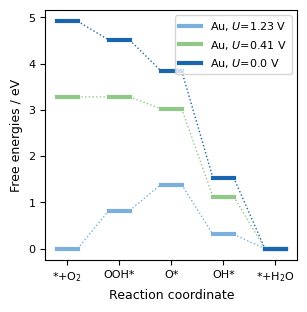

In [37]:
##-Plotting the diagram
plt.figure()

metal = "Au"
Es = [
    df[(df['metal'] == metal) & (df['adsorbate'] == 'OOH')]['adsorption_energy'].values[0],
    df[(df['metal'] == metal) & (df['adsorbate'] == 'O')]['adsorption_energy'].values[0],
    df[(df['metal'] == metal) & (df['adsorbate'] == 'OH')]['adsorption_energy'].values[0],
    ]

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2)

##-Plot for different potentials
plot_at_U(1.23,    Es, colors[1], metal)
plot_at_U(round(1.23-UL,2), Es, colors[2], metal)
plot_at_U(0.00,    Es, colors[0], metal)

plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ["*+O$_2$", "OOH*", "O*", "OH*", "*+H$_2$O"])

plt.legend()
plt.show()

## Summary

After completing this notebook, you should be able to:
1. Encapsulate calculator setup, slab relaxation, adsorbate placement, and adsorption energy calculation into named functions so that changing the metal or adsorbate requires only a single argument, not a rewrite of the block.
2.  Apply ZPE and solvation corrections. Add empirical corrections for zero-point energy and solvation to raw total energy differences for O, OH, and OOH intermediates, and understand why these corrections are typically taken from the literature rather than recomputed for each system.
3. Use the Computational Hydrogen Electrode. Express the free energy of each ORR intermediate as a function of electrode potential U by subtracting nU per electron transferred, using H₂ as the proton-electron reference. Compute the limiting potential as the smallest U at which all four steps become thermodynamically downhill, and extract the overpotential as its deviation from 1.23 V.
4. Plot multi-potential free energy diagrams. Use the plot_at_U() function to draw horizontal state bars connected by dotted transition lines at any chosen potential, overlay results at 0 V, the equilibrium potential, and the limiting potential on a single figure, and label the x-axis with intermediate names.
5. Read ASE databases and build DataFrames. Connect to .db files with ase.db.connect(), filter rows by metadata fields (functional, adsorption site, energy availability), and populate a pandas DataFrame for systematic multi-metal comparison.
6. Benchmark semiempirical against DFT results. Retrieve BEEF-vdW molecular reference energies from a curated database, apply the same adsorption energy expressions used with UMA, and plot the free energy diagram for a second metal to assess how well the machine-learning potential reproduces DFT trends.